# Recruit Restaurant Visitor Forecasting — 전처리 & EDA Notebook

## 0. 프로젝트 개요

| 구분 | 핵심 내용 |
|---|---|
| 대회/데이터 | Kaggle `Recruit Restaurant Visitor Forecasting` |
| 문제 정의 | 식당별·날짜별 방문자 수를 예측해 식당의 일별 운영 준비를 더 정교하게 만드는 문제 |
| 분석 단위 | `air_store_id × visit_date` |
| 타깃 변수 | `visitors` = 특정 식당의 특정 날짜 실제 방문자 수 |
| 문제 유형 | 회귀 문제 + 시계열 예측 성격 |
| 핵심 사용자 | 식당 점주 / 매장 운영자 |
| 핵심 가치 1 | **피크 수요 대응**: 사람이 많이 올 날에 인력·재고를 얼마나 준비할지 판단 |
| 핵심 가치 2 | **저수요 후보일 보완**: 사람이 적게 올 날에 프로모션·발주·근무를 어떻게 조정할지 판단 |
| 핵심 가치 3 | **예약 기반 조기 감지**: 며칠 전부터 수요 변화를 감지할 수 있는지 확인 |
| 모델링 연결 | Baseline → Ridge Regression → LightGBM → SHAP 해석 → 운영 액션 시뮬레이션 |

## 식당 점주 관점의 비즈니스 가치 3가지

| 번호 | 점주의 질문 | 분석 관점 | 기대 액션 |
|---:|---|---|---|
| 1 | 사람이 많이 올 날에는 얼마나 준비해야 하지? | 피크 수요 예측 | 인력 추가, 재료 추가 발주, 예약 슬롯 조정 |
| 2 | 사람이 적게 올 날에는 어떻게 빈 테이블을 줄이지? | 저수요 후보일 예측 | 쿠폰/프로모션, 발주 축소, 근무 인원 조정 |
| 3 | 그걸 며칠 전에 알 수 있는 신호는 없을까? | 예약 기반 조기 수요 감지 | D-3/D-7 시점 운영 계획 조정 |

## 분석 방향

| 단계 | 목적 | 산출물 |
|---|---|---|
| 데이터 구조 확인 | 각 CSV의 역할과 연결 구조 확인 | 데이터 사전, AIR/HPG 관계 정리 |
| 전처리 | 식당×날짜 단위의 master table 생성 | `train_master`, `test_master` |
| EDA | 방문자 수·요일·공휴일·카테고리·예약 패턴 확인 | 모델 피처 설계 근거 |
| 피처 설계 | 날짜, 식당, 예약, 과거 방문 패턴을 변수화 | Baseline/Ridge/LightGBM 입력 후보 |


---
# 1. 환경 설정 및 원본 데이터 로드

분석에 필요한 원본 CSV·라이브러리 호출, 필요한 공통 함수를 정의합니다.  
원본 데이터에서 `train_master`와 `test_master`를 생성하는 흐름까지 포함합니다.

In [10]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

BASE_PATH = Path('./raw_file')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)

# 차트는 기본 matplotlib 스타일을 사용합니다.
# 한글 폰트 환경이 다를 수 있어 그래프 제목/축은 영문 중심으로 작성하고, 해석은 마크다운에서 설명합니다.
print('환경 설정 완료')
print('데이터 경로:', BASE_PATH)

환경 설정 완료
데이터 경로: raw_file


In [11]:
# 원본 파일의 행/컬럼 수를 확인하는 함수입니다.
# hpg_reserve.csv처럼 큰 파일은 전체 DataFrame으로 읽지 않고, 헤더와 줄 수만 확인합니다.
def csv_shape(path):
    cols = pd.read_csv(path, nrows=0).shape[1]
    rows = sum(1 for _ in open(path, encoding='utf-8')) - 1
    return rows, cols

files = [
    ('air_visit_data.csv', 'AIR 식당의 실제 일별 방문자 수 (정답 데이터)'),
    ('air_store_info.csv', 'AIR 식당 카테고리/지역/위치 정보'),
    ('air_reserve.csv', 'AIR 식당 예약 정보'),
    ('hpg_reserve.csv', 'HPG 예약 정보'),
    ('hpg_store_info.csv', 'HPG 식당 카테고리/지역/위치 정보'),
    ('store_id_relation.csv', 'AIR-HPG 식당 ID 매핑'),
    ('date_info.csv', '요일/공휴일 캘린더'),
    ('sample_submission.csv', '미래 예측 대상 식당×날짜'),
]

schema_rows = []
for fname, role in files:
    rows, cols = csv_shape(BASE_PATH / fname)
    schema_rows.append({'file': fname, 'rows': rows, 'cols': cols, 'role': role})

schema_summary = pd.DataFrame(schema_rows)
schema_summary

,file,rows,cols,role
0,air_visit_data.csv,252108,3,AIR 식당의 실제 일별 방문자 수 (정답 데이터)
1,air_store_info.csv,829,5,AIR 식당 카테고리/지역/위치 정보
2,air_reserve.csv,92378,4,AIR 식당 예약 정보
3,hpg_reserve.csv,2000320,4,HPG 예약 정보
4,hpg_store_info.csv,4690,5,HPG 식당 카테고리/지역/위치 정보
5,store_id_relation.csv,150,2,AIR-HPG 식당 ID 매핑
6,date_info.csv,517,3,요일/공휴일 캘린더
7,sample_submission.csv,32019,2,미래 예측 대상 식당×날짜


### 해석
해당 대회는 단일 테이블을 바로 모델에 넣는 문제가 아닙니다.     
실제 방문자 수를 담은 `air_visit_data.csv`를 기준으로 날짜, 식당 카테고리/지역, 예약 정보를 결합해야 합니다.

### 1-1. 원본 데이터 구조 해석

| 원본 데이터 | 핵심 역할 |
|---|---|
| 방문 데이터 `air_visit_data.csv` | 모델이 맞춰야 하는 정답 `visitors` 제공 |
| 날짜 데이터 `date_info.csv` | 요일·주말·공휴일 효과 반영 |
| 식당 데이터 `air_store_info.csv` | 카테고리·지역에 따른 수요 차이 반영 |
| 예약 데이터 `air_reserve.csv`, `hpg_reserve.csv` | 방문 예정일 이전에 관측되는 예약 기반 선행 신호 |
| ID 매핑 `store_id_relation.csv` | HPG 예약을 AIR 식당 기준으로 연결 |

#### AIR와 HPG의 의미

| 구분 | 의미 | 본 분석에서의 사용 방식 |
|---|---|---|
| AIR | 실제 방문자 수 예측의 기준이 되는 식당 ID 체계입니다. 최종 타깃 `visitors`는 `air_store_id` 기준으로 기록되어 있습니다. | 분석과 모델링의 기준 키로 사용합니다. |
| HPG | AIR와 별도로 제공되는 예약/식당 정보의 ID 체계입니다. | `store_id_relation.csv`로 AIR 식당과 연결 가능한 데이터만 보조 예약 피처로 사용합니다. |

핵심은 최종 예측 대상이 AIR 식당의 방문자 수라는 점입니다.  
따라서 HPG 예약 데이터는 `store_id_relation.csv`로 AIR 식당과 연결 가능한 경우에만 사용하며, 전체 수요를 대표하기보다는 일부 식당의 보조 예약 신호로 해석합니다.


---
# 2. 원본 데이터 로드 및 Master Table 생성

최종 분석 단위는 `air_store_id × visit_date`입니다.  
예약 데이터는 시간 단위로 기록되어 있으므로, 방문일 기준으로 집계한 뒤 master table에 병합합니다.      
즉, 한 행은 “특정 식당의 특정 날짜 방문자 수와 그날의 날짜·식당·예약·과거 방문 패턴”을 의미합니다.

In [12]:
# 원본 데이터를 로드합니다.
# parse_dates는 날짜 컬럼을 datetime 타입으로 읽기 위한 옵션입니다.
air_visit = pd.read_csv(BASE_PATH / 'air_visit_data.csv', parse_dates=['visit_date'])
air_store = pd.read_csv(BASE_PATH / 'air_store_info.csv')
air_reserve = pd.read_csv(BASE_PATH / 'air_reserve.csv')
relation = pd.read_csv(BASE_PATH / 'store_id_relation.csv')
date_info = pd.read_csv(BASE_PATH / 'date_info.csv')
sample = pd.read_csv(BASE_PATH / 'sample_submission.csv')

# hpg_reserve.csv는 큰 파일이므로, 이후 단계에서 AIR와 매핑되는 행만 chunk 단위로 읽습니다.
hpg_reserve_total_rows = int(schema_summary.loc[schema_summary['file'] == 'hpg_reserve.csv', 'rows'].iloc[0])

print('원본 데이터 로드 완료')
print('air_visit:', air_visit.shape)
print('air_store:', air_store.shape)
print('air_reserve:', air_reserve.shape)
print('hpg_reserve total rows:', hpg_reserve_total_rows)
print('sample:', sample.shape)

원본 데이터 로드 완료
air_visit: (252108, 3)
air_store: (829, 5)
air_reserve: (92378, 4)
hpg_reserve total rows: 2000320
sample: (32019, 2)


In [13]:
# 원본 컬럼명은 air_genre_name이지만, 본 분석에서는 식당 유형을 '카테고리'로 표현합니다.
# 따라서 보고서/그래프/해석에서 일관되게 사용할 수 있도록 컬럼명을 변경합니다.
# area_name은 공백 기준으로 넓은 지역 단위를 추출해, 지역별 EDA에 활용합니다.
air_store = air_store.rename(columns={'air_genre_name': 'air_category_name'})

area_parts = air_store['air_area_name'].str.split(' ', expand=True)
air_store['area_level_1'] = area_parts[0]
air_store['area_level_2'] = area_parts[1].fillna('Unknown') if area_parts.shape[1] > 1 else 'Unknown'

# 날짜 정보도 visit_date라는 공통 키로 맞춥니다.
date_info = date_info.rename(columns={'calendar_date': 'visit_date'})
date_info['visit_date'] = pd.to_datetime(date_info['visit_date'])

dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_map = {day: i for i, day in enumerate(dow_order)}

date_info['dow_num'] = date_info['day_of_week'].map(dow_map)
date_info['is_weekend'] = date_info['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)
date_info = date_info.sort_values('visit_date').reset_index(drop=True)

# 공휴일 자체뿐 아니라 공휴일 전후도 수요에 영향을 줄 수 있어 파생변수로 만듭니다.
date_info['prev_day_holiday'] = date_info['holiday_flg'].shift(1).fillna(0).astype(int)
date_info['next_day_holiday'] = date_info['holiday_flg'].shift(-1).fillna(0).astype(int)
date_info['month'] = date_info['visit_date'].dt.month
date_info['day'] = date_info['visit_date'].dt.day
date_info['weekofyear'] = date_info['visit_date'].dt.isocalendar().week.astype(int)

# sample_submission의 id는 air_store_id와 예측 날짜가 결합된 형태이므로 분리합니다.
sample[['air_store_id', 'visit_date']] = sample['id'].str.rsplit('_', n=1, expand=True)
sample['visit_date'] = pd.to_datetime(sample['visit_date'])
test_base = sample[['id', 'air_store_id', 'visit_date']].copy()

print('날짜/식당 기본 전처리 완료')

날짜/식당 기본 전처리 완료


In [14]:
# 예약 원본은 '예약 1건 = 1행' 구조입니다.
# 반면 예측 타깃은 '식당 1곳 × 날짜 1일 = 1행' 구조입니다.
# 예약 데이터를 그대로 merge하면 한 날짜에 예약이 여러 건 있는 경우 행이 중복 증가합니다.
# 따라서 예약 정보를 식당×방문일 단위로 먼저 집계합니다.
def process_reserve(df, id_col, prefix):
    d = df.copy()
    d['visit_datetime'] = pd.to_datetime(d['visit_datetime'])
    d['reserve_datetime'] = pd.to_datetime(d['reserve_datetime'])
    d['visit_date'] = d['visit_datetime'].dt.floor('D')

    # 리드타임은 예약 생성 시점과 실제 방문 예정 시점의 차이입니다.
    # 점주가 며칠 전에 수요를 감지할 수 있는지 보여주는 핵심 피처입니다.
    d['lead_time_hours'] = (d['visit_datetime'] - d['reserve_datetime']).dt.total_seconds() / 3600
    d['lead_time_days'] = d['lead_time_hours'] / 24

    # D-1, D-3, D-7 피처는 특정 시점까지 이미 확보된 예약량을 의미합니다.
    # 예: D-3 예약 인원 = 방문 3일 전까지 들어온 예약 인원
    for n in [1, 3, 7]:
        d[f'reserve_visitors_d{n}'] = np.where(d['lead_time_days'] >= n, d['reserve_visitors'], 0)
        d[f'reserve_count_d{n}'] = np.where(d['lead_time_days'] >= n, 1, 0)

    agg = (
        d.groupby([id_col, 'visit_date'])
        .agg(
            reserve_count=('reserve_visitors', 'size'),
            reserve_visitors_sum=('reserve_visitors', 'sum'),
            reserve_visitors_mean=('reserve_visitors', 'mean'),
            reserve_visitors_max=('reserve_visitors', 'max'),
            lead_time_mean=('lead_time_hours', 'mean'),
            lead_time_median=('lead_time_hours', 'median'),
            lead_time_min=('lead_time_hours', 'min'),
            lead_time_max=('lead_time_hours', 'max'),
            reserve_visitors_d1=('reserve_visitors_d1', 'sum'),
            reserve_visitors_d3=('reserve_visitors_d3', 'sum'),
            reserve_visitors_d7=('reserve_visitors_d7', 'sum'),
            reserve_count_d1=('reserve_count_d1', 'sum'),
            reserve_count_d3=('reserve_count_d3', 'sum'),
            reserve_count_d7=('reserve_count_d7', 'sum'),
        )
        .reset_index()
    )

    rename_cols = {c: f'{prefix}_{c}' for c in agg.columns if c not in [id_col, 'visit_date']}
    agg = agg.rename(columns=rename_cols)

    if id_col != 'air_store_id':
        agg = agg.rename(columns={id_col: 'air_store_id'})

    return agg

# hpg_reserve.csv는 크기 때문에, AIR와 연결 가능한 예약만 chunk 단위로 읽습니다.
# 전체 파일을 모두 메모리에 올리지 않아도 되므로 실행 안정성이 좋아집니다.
def load_mapped_hpg_reserve(hpg_path, relation_df, chunksize=300_000):
    mapped_hpg_ids = set(relation_df['hpg_store_id'])
    chunks = []
    for chunk in pd.read_csv(hpg_path, chunksize=chunksize):
        chunk = chunk[chunk['hpg_store_id'].isin(mapped_hpg_ids)]
        if not chunk.empty:
            chunk = chunk.merge(relation_df, on='hpg_store_id', how='inner')
            chunks.append(chunk[['air_store_id', 'visit_datetime', 'reserve_datetime', 'reserve_visitors']])
    if chunks:
        return pd.concat(chunks, ignore_index=True)
    return pd.DataFrame(columns=['air_store_id', 'visit_datetime', 'reserve_datetime', 'reserve_visitors'])

# AIR 예약은 air_store_id 기준이므로 바로 집계할 수 있습니다.
air_reserve_agg = process_reserve(air_reserve, id_col='air_store_id', prefix='air')

# HPG 예약은 AIR 식당과 연결되는 건만 추출한 뒤 같은 방식으로 집계합니다.
hpg_mapped = load_mapped_hpg_reserve(BASE_PATH / 'hpg_reserve.csv', relation)
hpg_reserve_agg = process_reserve(hpg_mapped, id_col='air_store_id', prefix='hpg')

reservation_coverage = pd.DataFrame({
    'source': ['AIR reserve', 'HPG reserve', 'HPG reserve mapped to AIR'],
    'rows': [len(air_reserve), hpg_reserve_total_rows, len(hpg_mapped)],
    'unique_air_stores': [air_reserve['air_store_id'].nunique(), np.nan, hpg_mapped['air_store_id'].nunique()],
    'meaning': [
        'AIR 기준 예약 정보',
        'HPG 전체 예약 정보',
        'AIR 식당 방문자 수 예측에 직접 연결 가능한 HPG 예약 정보'
    ]
})
reservation_coverage


,source,rows,unique_air_stores,meaning
0,AIR reserve,92378,314.0,AIR 기준 예약 정보
1,HPG reserve,2000320,NaN,HPG 전체 예약 정보
2,HPG reserve mapped to AIR,28183,150.0,AIR 식당 방문자 수 예측에 직접 연결 가능한 HPG 예약 정보


### 2-1. 예약 데이터 집계 해석

예약 데이터는 `예약 1건 = 1행` 구조이고, 예측 타깃은 `식당×날짜 = 1행` 구조입니다.  
따라서 예약 데이터를 그대로 병합하면 같은 식당·날짜 행이 여러 개로 늘어날 수 있어, 먼저 식당×방문일 단위로 집계했습니다.

| 집계 피처 | 의미 | 활용 |
|---|---|---|
| 예약 건수 | 해당 날짜에 예약이 몇 건 있었는지 | 예약 수요 강도 |
| 예약 인원 합계 | 해당 날짜에 예약된 총 인원 | 방문자 수 선행 신호 |
| 리드타임 | 방문 예정일보다 며칠 전에 예약했는지 | 조기 감지 가능성 |
| D-1/D-3/D-7 예약량 | 특정 시점까지 확보된 예약량 | 사전 대응 시점 분석 |


In [15]:
# train/test 모두 같은 방식으로 날짜, 식당, 예약 정보를 병합합니다.
def merge_base(df, is_train=True):
    out = df.copy()
    out = out.merge(date_info, on='visit_date', how='left')
    out = out.merge(air_store, on='air_store_id', how='left')
    out = out.merge(air_reserve_agg, on=['air_store_id', 'visit_date'], how='left')
    out = out.merge(hpg_reserve_agg, on=['air_store_id', 'visit_date'], how='left')

    # 예약 관련 결측은 대부분 '예약이 없음'을 의미하므로 0으로 채웁니다.
    reserve_cols = [
        c for c in out.columns
        if c.startswith('air_reserve') or c.startswith('air_lead') or c.startswith('hpg_reserve') or c.startswith('hpg_lead')
    ]
    for c in reserve_cols:
        out[c] = out[c].fillna(0)

    # AIR와 HPG 예약 신호를 합산해 전체 예약량 피처를 만듭니다.
    # 이 값은 예약 플랫폼 구분보다 '해당 식당의 방문 예정일에 이미 확보된 예약 신호'를 보는 데 사용합니다.
    out['total_reserve_count'] = out.get('air_reserve_count', 0) + out.get('hpg_reserve_count', 0)
    out['total_reserve_visitors_sum'] = out.get('air_reserve_visitors_sum', 0) + out.get('hpg_reserve_visitors_sum', 0)
    out['total_reserve_exists'] = (out['total_reserve_count'] > 0).astype(int)
    out['total_reserve_visitors_mean'] = np.where(
        out['total_reserve_count'] > 0,
        out['total_reserve_visitors_sum'] / out['total_reserve_count'],
        0
    )

    # D-1/D-3/D-7 기준으로 AIR와 HPG 예약량을 합산합니다.
    # 이 피처는 “며칠 전에 수요를 감지할 수 있는가?”를 모델링에서 직접 확인하기 위한 변수입니다.
    for n in [1, 3, 7]:
        out[f'total_reserve_visitors_d{n}'] = (
            out.get(f'air_reserve_visitors_d{n}', 0) + out.get(f'hpg_reserve_visitors_d{n}', 0)
        )
        out[f'total_reserve_count_d{n}'] = (
            out.get(f'air_reserve_count_d{n}', 0) + out.get(f'hpg_reserve_count_d{n}', 0)
        )
    return out

train_master = merge_base(air_visit, is_train=True)
test_master = merge_base(test_base, is_train=False)

print('기본 master table 생성 완료')
print('train_master:', train_master.shape)
print('test_master :', test_master.shape)


기본 master table 생성 완료
train_master: (252108, 56)
test_master : (32019, 56)


In [16]:
# 과거 방문 패턴 피처를 생성합니다.
# 주의: 특정 날짜를 예측할 때 그 날짜의 실제 방문자 수가 피처에 들어가면 데이터 누수가 발생합니다.
# 따라서 train에서는 shift(1)을 사용해 '이전 기록'만 기반으로 평균/이동평균을 만듭니다.
train_master = train_master.sort_values(['air_store_id', 'visit_date']).reset_index(drop=True)
global_mean = train_master['visitors'].mean()

train_master['store_prior_mean'] = (
    train_master.groupby('air_store_id')['visitors']
    .transform(lambda s: s.shift(1).expanding().mean())
)
train_master['store_dow_prior_mean'] = (
    train_master.groupby(['air_store_id', 'dow_num'])['visitors']
    .transform(lambda s: s.shift(1).expanding().mean())
)

for window in [7, 14, 28]:
    train_master[f'rolling_{window}_mean'] = (
        train_master.groupby('air_store_id')['visitors']
        .transform(lambda s, window=window: s.shift(1).rolling(window, min_periods=1).mean())
    )
    train_master[f'rolling_{window}_std'] = (
        train_master.groupby('air_store_id')['visitors']
        .transform(lambda s, window=window: s.shift(1).rolling(window, min_periods=2).std())
    )

# 첫 관측일처럼 과거 정보가 없는 경우는 전체 평균 또는 이전 평균으로 보완합니다.
train_master['store_prior_mean'] = train_master['store_prior_mean'].fillna(global_mean)
train_master['store_dow_prior_mean'] = train_master['store_dow_prior_mean'].fillna(train_master['store_prior_mean']).fillna(global_mean)
for window in [7, 14, 28]:
    train_master[f'rolling_{window}_mean'] = train_master[f'rolling_{window}_mean'].fillna(train_master['store_prior_mean']).fillna(global_mean)
    train_master[f'rolling_{window}_std'] = train_master[f'rolling_{window}_std'].fillna(0)

# 아래 *_for_eda 컬럼은 전체 train 기간을 기준으로 계산한 EDA/해석용 기준값입니다.
# validation 모델링 피처로 그대로 사용하면 데이터 누수 가능성이 있으므로,
# 실제 모델 학습에는 shift 기반 prior/rolling 피처를 우선 사용합니다.
store_mean = train_master.groupby('air_store_id')['visitors'].mean()
store_dow_mean = train_master.groupby(['air_store_id', 'dow_num'])['visitors'].mean()
category_mean = train_master.groupby('air_category_name')['visitors'].mean()
area_mean = train_master.groupby('area_level_1')['visitors'].mean()

train_master['store_mean_for_eda'] = train_master['air_store_id'].map(store_mean)
train_master['store_dow_mean_for_eda'] = train_master.set_index(['air_store_id', 'dow_num']).index.map(store_dow_mean)
train_master['category_mean_for_eda'] = train_master['air_category_name'].map(category_mean)
train_master['area_mean_for_eda'] = train_master['area_level_1'].map(area_mean)

# test는 미래 데이터이므로, train에서 계산된 식당별/요일별 평균과 최근 방문 통계만 사용합니다.
test_master['store_prior_mean'] = test_master['air_store_id'].map(store_mean).fillna(global_mean)
test_master['store_dow_prior_mean'] = test_master.set_index(['air_store_id', 'dow_num']).index.map(store_dow_mean)
test_master['store_dow_prior_mean'] = test_master['store_dow_prior_mean'].fillna(test_master['store_prior_mean']).fillna(global_mean)
test_master['category_mean_for_eda'] = test_master['air_category_name'].map(category_mean).fillna(global_mean)
test_master['area_mean_for_eda'] = test_master['area_level_1'].map(area_mean).fillna(global_mean)

for window in [7, 14, 28]:
    recent_stats = (
        train_master.sort_values('visit_date')
        .groupby('air_store_id')['visitors']
        .apply(lambda s, window=window: pd.Series({
            'mean': s.tail(window).mean(),
            'std': s.tail(window).std()
        }))
        .unstack()
    )
    test_master[f'rolling_{window}_mean'] = (
        test_master['air_store_id']
        .map(recent_stats['mean'])
        .fillna(test_master['store_prior_mean'])
        .fillna(global_mean)
    )
    test_master[f'rolling_{window}_std'] = (
        test_master['air_store_id']
        .map(recent_stats['std'])
        .fillna(0)
    )

# 모델 타깃과 로그 변환 타깃을 함께 준비합니다.
train_master['log_visitors'] = np.log1p(train_master['visitors'])

print('과거 방문 패턴 피처 생성 완료')


과거 방문 패턴 피처 생성 완료


### 2-2. Master Table 생성 해석

| 처리 내용 | 의미 | 모델링 반영 |
|---|---|---|
| 날짜/식당 정보 병합 | 각 방문 기록에 요일, 공휴일, 카테고리, 지역 정보를 붙였습니다. | Ridge/LightGBM의 기본 설명 변수로 사용합니다. |
| 예약 정보 집계 | 예약 건수·예약 인원·리드타임을 식당×방문일 단위로 정리했습니다. | 예약 기반 조기 감지와 SHAP 해석의 핵심 피처입니다. |
| 과거 방문 피처 생성 | 식당별 평균, 식당×요일 평균, 최근 이동평균을 만들었습니다. | Baseline과 ML 모델 모두에서 가장 중요한 기준선 후보입니다. |
| `shift(1)` 적용 | 예측일의 실제 방문자 수가 과거 평균에 섞이지 않도록 했습니다. | 시계열 데이터 누수 위험을 낮춥니다. |

이 단계에서 생성된 `train_master`와 `test_master`는 이후 EDA와 모델링에서 동일한 기준으로 사용할 수 있는 기본 테이블입니다.       
특히 train/test 모두 같은 방식으로 날짜·식당·예약 피처를 갖도록 맞췄기 때문에, 학습 데이터에서 만든 모델을 예측 데이터에 그대로 적용할 수 있습니다.

---
# 3. Master Table 구조 확인

학습/예측 기간, 식당 수, 주요 컬럼을 확인합니다.  
이 단계에서는 “분석 단위가 제대로 맞춰졌는지”와 “train/test가 같은 구조를 갖는지”가 핵심입니다.

In [17]:
coverage_summary = pd.DataFrame({
    'dataset': ['train_master', 'test_master'],
    'start_date': [train_master['visit_date'].min(), test_master['visit_date'].min()],
    'end_date': [train_master['visit_date'].max(), test_master['visit_date'].max()],
    'unique_stores': [train_master['air_store_id'].nunique(), test_master['air_store_id'].nunique()],
    'rows': [len(train_master), len(test_master)],
    'has_target_visitors': [train_master['visitors'].notna().all(), 'No target in test']
})
coverage_summary

,dataset,start_date,end_date,unique_stores,rows,has_target_visitors
0,train_master,2016-01-01,2017-04-22,829,252108,True
1,test_master,2017-04-23,2017-05-31,821,32019,No target in test


### 3-1. 기간·식당 수 해석

| 확인 포인트 | 해석 |
|---|---|
| 학습 기간 | 2016-01-01 ~ 2017-04-22까지 실제 방문자 수가 존재합니다. |
| 예측 기간 | 2017-04-23 ~ 2017-05-31의 미래 방문자 수를 예측해야 합니다. |
| 학습 식당 수 | 829개 AIR 식당의 방문 기록을 학습에 사용합니다. |
| 예측 식당 수 | 821개 AIR 식당에 대해 예측값을 생성해야 합니다. |

학습 데이터는 실제 방문자 수가 있는 과거 기간이고, 테스트 데이터는 이후 미래 기간입니다.  
따라서 이 문제는 랜덤 샘플 예측이 아니라, 과거 데이터를 기반으로 미래 방문자 수를 예측하는 구조입니다.

| 확인 포인트 | 의미 |
|---|---|
| train과 test의 기간이 분리 | 시계열 예측 성격이 있음 |
| test에는 `visitors` 정답 없음 | 같은 피처 구조를 만든 뒤 모델로 예측해야 함 |
| 분석 단위가 식당×날짜 | 식당 점주의 일별 운영 의사결정 단위와 일치 |

In [18]:
preview_cols = [
    'air_store_id', 'visit_date', 'visitors', 'day_of_week', 'holiday_flg',
    'air_category_name', 'area_level_1',
    'total_reserve_count', 'total_reserve_visitors_sum',
    'store_prior_mean', 'store_dow_prior_mean', 'rolling_7_mean', 'rolling_28_mean'
]
train_master[preview_cols].head()

,air_store_id,visit_date,visitors,day_of_week,holiday_flg,air_category_name,area_level_1,total_reserve_count,total_reserve_visitors_sum,store_prior_mean,store_dow_prior_mean,rolling_7_mean,rolling_28_mean
0,air_00a91d42b08b08d9,2016-07-01,35,Friday,0,Italian/French,Tōkyō-to,1.0,1.0,20.973761,20.973761,20.973761,20.973761
1,air_00a91d42b08b08d9,2016-07-02,9,Saturday,0,Italian/French,Tōkyō-to,0.0,0.0,35.000000,35.000000,35.000000,35.000000
2,air_00a91d42b08b08d9,2016-07-04,20,Monday,0,Italian/French,Tōkyō-to,0.0,0.0,22.000000,22.000000,22.000000,22.000000
3,air_00a91d42b08b08d9,2016-07-05,25,Tuesday,0,Italian/French,Tōkyō-to,0.0,0.0,21.333333,21.333333,21.333333,21.333333
4,air_00a91d42b08b08d9,2016-07-06,29,Wednesday,0,Italian/French,Tōkyō-to,1.0,7.0,22.250000,22.250000,22.250000,22.250000


### 3-2. 주요 컬럼 미리보기 해석

| 컬럼 그룹 | 의미 | 확인할 점 |
|---|---|---|
| Key | `air_store_id`, `visit_date` | 한 행이 특정 식당의 특정 날짜를 의미하는지 확인합니다. |
| Target | `visitors` | 모델이 예측해야 할 실제 방문자 수입니다. |
| 날짜 피처 | `day_of_week`, `holiday_flg` | 요일·공휴일에 따른 수요 차이를 반영합니다. |
| 식당 피처 | `air_category_name`, `area_level_1` | 카테고리·지역별 기본 수요 차이를 반영합니다. |
| 예약 피처 | `total_reserve_count`, `total_reserve_visitors_sum` | 방문일 이전에 관측 가능한 수요 신호입니다. |
| 과거 방문 피처 | `store_prior_mean`, `store_dow_prior_mean`, `rolling_*` | 평균 기반 Baseline과 ML 모델의 핵심 입력 후보입니다. |

---
# 4. 전처리 로직 요약

아래 표는 master table이 만들어지는 전처리 흐름입니다.     
코드를 세부적으로 읽지 않더라도, 어떤 데이터가 어떤 목적의 피처로 바뀌었는지 파악할 수 있습니다.

In [19]:
preprocess_summary = pd.DataFrame([
    ['날짜 변환', 'visit_date, visit_datetime, reserve_datetime', '요일·월·공휴일·리드타임 생성을 위해 datetime 변환'],
    ['식당 정보 병합', 'air_store_info', '카테고리, 지역, 위도/경도 정보 추가'],
    ['예약 정보 집계', 'air_reserve, hpg_reserve', '예약 건수, 예약 인원, 리드타임을 식당×방문일 단위로 집계'],
    ['HPG 매핑', 'store_id_relation', 'HPG 예약 중 AIR 식당과 연결 가능한 데이터만 보조 신호로 사용'],
    ['예약 결측 처리', 'reserve_* columns', '예약이 없는 날은 0으로 처리하고 예약 존재 플래그 생성'],
    ['과거 방문 피처', 'store_prior_mean, rolling_*', '식당별 기본 수요와 최근 추세를 반영'],
    ['비즈니스 플래그', 'peak/low demand candidate', '피크일·저수요 후보일 분석을 위한 후보 라벨 생성'],
], columns=['step', 'source_or_column', 'purpose'])
preprocess_summary

,step,source_or_column,purpose
0,날짜 변환,"visit_date, visit_datetime, reserve_datetime",요일·월·공휴일·리드타임 생성을 위해 datetime 변환
1,식당 정보 병합,air_store_info,"카테고리, 지역, 위도/경도 정보 추가"
2,예약 정보 집계,"air_reserve, hpg_reserve","예약 건수, 예약 인원, 리드타임을 식당×방문일 단위로 집계"
3,HPG 매핑,store_id_relation,HPG 예약 중 AIR 식당과 연결 가능한 데이터만 보조 신호로 사용
4,예약 결측 처리,reserve_* columns,예약이 없는 날은 0으로 처리하고 예약 존재 플래그 생성
5,과거 방문 피처,"store_prior_mean, rolling_*",식당별 기본 수요와 최근 추세를 반영
6,비즈니스 플래그,peak/low demand candidate,피크일·저수요 후보일 분석을 위한 후보 라벨 생성


### 4-1. 전처리 요약 해석

해당 데이터의 전처리는 식당 점주의 운영 질문을 모델이 학습할 수 있는 숫자와 범주형 피처로 바꾸는 것이 중요합니다.

| 관점 | 핵심 해석 |
|---|---|
| 데이터 병합 | 모든 원본 데이터는 최종적으로 `air_store_id × visit_date` 단위로 맞춰졌습니다. |
| 예약 데이터 | 예약은 전체 방문자를 대체하는 값이 아니라, 미래 수요를 미리 알려주는 선행 신호로 사용합니다. |
| 과거 방문 피처 | 식당별 평균과 이동평균은 “이 식당이 원래 어느 정도 오는 곳인지”를 반영합니다. |
| 모델링 연결 | Baseline은 평균 피처를, Ridge/LightGBM은 날짜·식당·예약·과거 방문 피처를 함께 사용하면 됩니다. |

---
# 5. 방문자 수 분포 EDA

타깃 변수 `visitors`의 분포를 확인합니다.  
분포를 보면 어떤 평가 지표와 로그 변환이 적절한지, 피크 수요와 저수요를 어떻게 다룰지 판단할 수 있습니다.

In [20]:
target_summary = (
    train_master['visitors']
    .describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
    .to_frame('visitors')
    .round(2)
)
target_summary

,visitors
count,252108.00
mean,20.97
std,16.76
min,1.00
25%,9.00
50%,17.00
75%,29.00
90%,43.00
95%,52.00
99%,73.00


### 5-1. 방문자 수 기초 통계 해석

| 관찰 | 해석 | 다음 반영 |
|---|---|---|
| 평균 21.0명, 중앙값 17명 | 평균이 중앙값보다 높아 일부 큰 방문자 수가 분포를 끌어올립니다. | 평균 오차만 보지 말고 RMSLE, MAE를 함께 봅니다. |
| 95% 분위수 52명 | 대부분의 관측치는 이보다 낮고, 일부 피크일이 존재합니다. | 큰 값을 단순 이상치로 제거하기보다 피크 수요 분석 대상으로 유지합니다. |
| 최대 877명 | 대형 피크 또는 대형 식당 효과가 존재합니다. | `log1p(visitors)` 변환과 피크일 별도 성능 확인이 필요합니다. |

In [21]:
low_visitor_share = pd.DataFrame({
    'threshold': ['≤5명', '≤10명', '≤20명', '≤50명'],
    'share_%': [
        (train_master['visitors'] <= 5).mean() * 100,
        (train_master['visitors'] <= 10).mean() * 100,
        (train_master['visitors'] <= 20).mean() * 100,
        (train_master['visitors'] <= 50).mean() * 100,
    ]
}).round(2)
low_visitor_share

,threshold,share_%
0,≤5명,13.56
1,≤10명,30.60
2,≤20명,58.72
3,≤50명,94.38


### 5-2. 낮은 방문자 수 구간 해석

| 관찰 | 해석 | 다음 반영 |
|---|---|---|
| 10명 이하 비중 30.6% | 방문자 수가 낮은 날짜가 상당수 존재합니다. | 저수요 후보일 탐지와 과대예측 감소가 중요한 운영 KPI가 됩니다. |
| 20명 이하 비중 58.7% | 전체 데이터의 절반 이상이 소규모 수요 구간에 포함됩니다. | 대형 식당 중심으로만 성능을 보지 말고, 작은 식당/저수요 후보일 성능도 확인해야 합니다. |

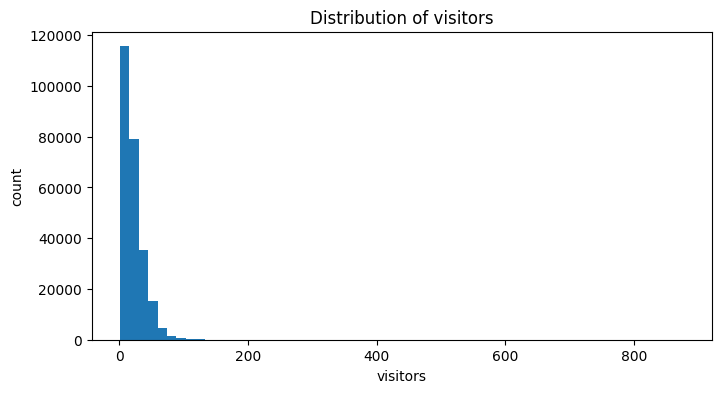

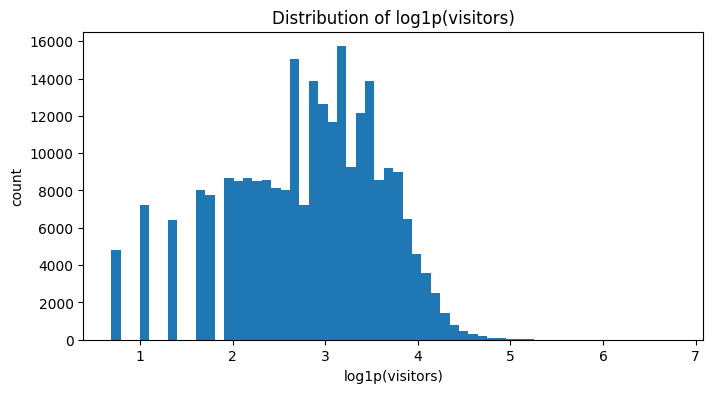

In [22]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(train_master['visitors'], bins=60)
ax.set_title('Distribution of visitors')
ax.set_xlabel('visitors')
ax.set_ylabel('count')
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(np.log1p(train_master['visitors']), bins=60)
ax.set_title('Distribution of log1p(visitors)')
ax.set_xlabel('log1p(visitors)')
ax.set_ylabel('count')
plt.show()

### 5-3. 분포 그래프 해석

방문자 수는 낮은 구간에 많이 몰려 있고, 일부 큰 값이 오른쪽 꼬리를 만드는 형태입니다.  
이는 이 프로젝트의 불균형이 분류 문제의 class imbalance가 아니라, **식당별 규모 차이와 low visitor 구간 집중**에 가깝다는 점을 보여줍니다.

| 그래프에서 보이는 점 | 의미 | 다음 반영 |
|---|---|---|
| 낮은 방문자 수 구간이 많음 | 소규모 식당 또는 한가한 날짜가 많음 | 저수요 후보일과 과대예측 분석 필요 |
| 일부 큰 방문자 수 존재 | 피크 수요 후보일 또는 대형 식당 효과 가능 | 큰 값을 제거하지 않고 피크 수요 분석에 활용 |
| 로그 변환 후 분포가 완화 | 큰 값의 영향이 줄어듦 | `log1p(visitors)`와 RMSLE 검토 |

---
# 6. 요일·공휴일별 방문 패턴

요일과 공휴일은 식당 점주의 인력·재고 계획에 바로 연결되는 변수입니다.  
요일별 수요 차이가 크다면, 식당×요일별 평균은 좋은 Baseline이 됩니다.

In [23]:
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_summary = (
    train_master.groupby('day_of_week')['visitors']
    .agg(['count', 'mean', 'median'])
    .reindex(dow_order)
    .round(2)
    .reset_index()
)
dow_summary

,day_of_week,count,mean,median
0,Monday,31682,17.18,14.0
1,Tuesday,36015,17.67,14.0
2,Wednesday,36811,19.23,16.0
3,Thursday,37996,18.92,16.0
4,Friday,40351,23.07,19.0
5,Saturday,39262,26.31,22.0
6,Sunday,29991,23.87,19.0


### 6-1. 요일별 방문 패턴 해석

| 관찰 | 해석 | 다음 반영 |
|---|---|---|
| 평균 방문자 수가 가장 높은 요일 | Saturday 약 26.3명 | 해당 요일은 피크 수요 대응 관점에서 중요합니다. |
| 평균 방문자 수가 가장 낮은 요일 | Monday 약 17.2명 | 저수요 후보일 보완 또는 근무/발주 축소 후보가 될 수 있습니다. |
| 요일 간 평균 차이 | 요일은 방문자 수의 기본 패턴을 설명하는 핵심 변수입니다. | `식당×요일 평균` Baseline과 `day_of_week` 피처를 반드시 사용합니다. |

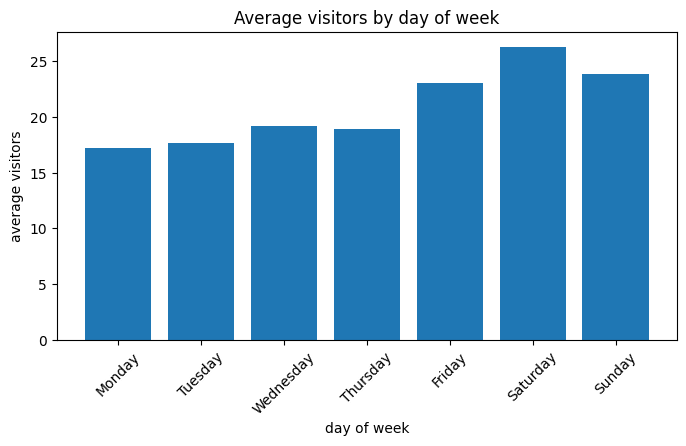

In [24]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(dow_summary['day_of_week'], dow_summary['mean'])
ax.set_title('Average visitors by day of week')
ax.set_xlabel('day of week')
ax.set_ylabel('average visitors')
ax.tick_params(axis='x', rotation=45)
plt.show()

### 6-2. 요일 그래프 해석

그래프에서는 금요일·토요일·일요일의 평균 방문자 수가 상대적으로 높고, 월요일은 낮은 패턴이 확인됩니다.  
다만 이는 전체 식당 평균이므로, 모든 식당에 동일하게 적용하기보다는 식당별 기준선과 함께 해석해야 합니다.

| 해석 포인트 | 다음 반영 |
|---|---|
| 요일별 평균 차이가 있음 | `day_of_week`, `is_weekend` 피처 유지 |
| 전체 평균만으로는 식당별 차이를 설명하기 어려움 | `store_dow_prior_mean` 사용 |
| 카테고리별로 강한 요일이 다를 수 있음 | LightGBM에서 카테고리×요일 상호작용 확인 |

In [25]:
holiday_summary = (
    train_master.groupby('holiday_flg')['visitors']
    .agg(['count', 'mean', 'median'])
    .round(2)
    .reset_index()
)
holiday_summary

,holiday_flg,count,mean,median
0,0,239333,20.83,17.0
1,1,12775,23.70,19.0


### 6-3. 공휴일 패턴 해석

| 관찰 | 해석 | 다음 반영 |
|---|---|---|
| 공휴일 평균 방문자 수는 약 23.7명 | 비공휴일 평균 약 20.8명보다 높습니다. | `holiday_flg`는 날짜 피처로 유지합니다. |
| 공휴일 표본 수는 비공휴일보다 적음 | 공휴일 평균만으로 모든 식당에 일반화하기는 어렵습니다. | 카테고리·지역·요일과 함께 해석합니다. |
| 공휴일 전후 효과 가능성 | 공휴일 당일보다 전날/다음날 수요가 더 중요할 수 있습니다. | `prev_day_holiday`, `next_day_holiday`를 함께 사용합니다. |

공휴일 효과는 단독 변수로만 보기보다 식당 카테고리, 지역, 요일과 함께 해석하는 것이 안전합니다. 특히 LightGBM에서는 이러한 조합 효과가 자동으로 반영될 수 있습니다.


---
# 7. 식당별 수요 규모 차이
 
방문자 수 예측에서 가장 중요한 기준은 “그 식당이 원래 어느 정도 손님이 오는 곳인가”입니다.  
식당별 기본 수요 차이를 확인하면, 왜 전체 평균이 아니라 식당별 평균이 필요한지 설명할 수 있습니다.

In [26]:
store_summary = (
    train_master.groupby('air_store_id')['visitors']
    .agg(['count','mean','median','std','min','max'])
    .round(2)
)
store_mean_summary = store_summary['mean'].describe(percentiles=[0.25,0.5,0.75,0.9,0.95,0.99]).to_frame('store_mean_visitors').round(2)
store_mean_summary

,store_mean_visitors
count,829.00
mean,21.20
std,11.78
min,1.19
25%,11.81
50%,19.18
75%,28.65
90%,36.68
95%,41.08
99%,50.02


### 7-1. 식당별 평균 방문자 수 해석

| 관찰 | 해석 | 다음 반영 |
|---|---|---|
| 식당별 평균 중앙값 | 약 19.2명 | 보통 규모의 식당 기준선을 이해할 수 있습니다. |
| 식당별 평균 최소~최대 | 1.2명 ~ 115.5명 | 식당별 규모 차이가 매우 큽니다. |
| 최대/최소 평균 차이 | 약 97.2배 | 전체 평균 하나로 모든 식당을 예측하는 방식은 부적절합니다. |

따라서 모델링에서는 식당별 평균, 식당×요일 평균, 최근 이동평균이 기본 피처로 반드시 필요합니다.

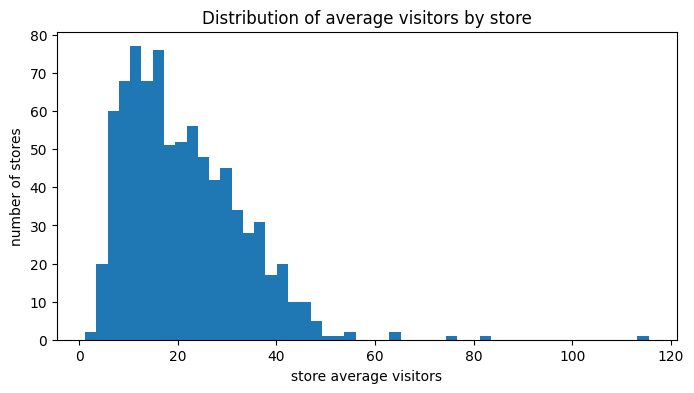

평균 방문자 수 상위 10개 식당


,air_store_id,air_category_name,air_area_name,count,mean,median,std,max
71,air_1c0b150f9e696a5f,Okonomiyaki/Monja/Teppanyaki,Tōkyō-to Shibuya-ku Shibuya,51,115.47,115.0,23.23,166
453,air_900d755ebd2f7bbd,Italian/French,Tōkyō-to Chūō-ku Ginza,20,82.20,83.5,29.24,125
510,air_9c6787aa03a45586,Cafe/Sweets,Tōkyō-to Chiyoda-ku Kudanminami,70,76.46,83.0,36.80,142
103,air_258dc112912fc458,Japanese food,Tōkyō-to Edogawa-ku Chūō,240,63.55,60.0,16.52,109
721,air_df554c4527a1cfe6,Izakaya,Shizuoka-ken Hamamatsu-shi Motoshirochō,166,63.00,56.0,39.23,205
379,air_789103bf53b8096b,Izakaya,Tōkyō-to Ōta-ku Kamiikedai,41,55.24,53.0,19.71,95
677,air_cf5ab75a0afb8af9,Yakiniku/Korean food,Miyagi-ken Sendai-shi Kamisugi,53,53.83,56.0,18.80,92
241,air_4feeb8600f131e43,Izakaya,Tōkyō-to Chūō-ku Tsukiji,228,53.14,57.5,17.79,85
706,air_d98380a4aeb0290b,Cafe/Sweets,Ōsaka-fu Sakai-shi Minamikawaramachi,220,50.85,48.0,29.24,328
496,air_99157b6163835eec,Cafe/Sweets,Shizuoka-ken Numazu-shi Miyukichō,378,47.88,43.0,19.80,115


평균 방문자 수 하위 10개 식당


,air_store_id,air_category_name,air_area_name,count,mean,median,std,max
530,air_a21ffca0bea1661a,Dining bar,Tōkyō-to Shinjuku-ku Kabukichō,160,1.19,1.0,0.78,10
609,air_bbe1c1a47e09f161,Dining bar,Tōkyō-to Setagaya-ku Kitazawa,220,2.64,1.0,4.06,33
821,air_fdcfef8bd859f650,Bar/Cocktail,Fukuoka-ken Fukuoka-shi Daimyō,174,3.59,3.0,2.34,17
270,air_5b704df317ed1962,Dining bar,Tōkyō-to Meguro-ku Kamimeguro,218,3.67,2.0,5.94,44
520,air_9dd7d38b0f1760c4,Cafe/Sweets,Fukuoka-ken Fukuoka-shi Shiobaru,217,3.70,3.0,2.37,12
501,air_9a6f6e7f623003d2,Dining bar,Fukuoka-ken Kurume-shi Jōnanmachi,194,4.24,3.0,6.37,77
662,air_caf996ac27206301,Dining bar,Tōkyō-to Nerima-ku Toyotamakita,257,4.37,4.0,2.77,13
692,air_d44d210d2994f01b,Bar/Cocktail,Tōkyō-to Setagaya-ku Setagaya,408,4.60,4.0,3.28,19
521,air_9e920b758503ef54,Cafe/Sweets,Fukuoka-ken Fukuoka-shi Daimyō,263,4.67,4.0,2.85,16
83,air_1f7f8fa557bc0d55,Bar/Cocktail,Ōsaka-fu Neyagawa-shi Honmachi,424,4.70,4.0,3.23,22


In [27]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(store_summary['mean'], bins=50)
ax.set_title('Distribution of average visitors by store')
ax.set_xlabel('store average visitors')
ax.set_ylabel('number of stores')
plt.show()

store_summary_with_info = store_summary.reset_index().merge(
    train_master[['air_store_id','air_category_name','air_area_name']].drop_duplicates(),
    on='air_store_id', how='left'
)
display_cols = ['air_store_id','air_category_name','air_area_name','count','mean','median','std','max']
print('평균 방문자 수 상위 10개 식당')
display(store_summary_with_info.sort_values('mean', ascending=False)[display_cols].head(10))
print('평균 방문자 수 하위 10개 식당')
display(store_summary_with_info.sort_values('mean', ascending=True)[display_cols].head(10))

### 7-2. 식당별 평균 분포 그래프 해석

그래프는 대부분의 식당이 낮거나 중간 수준의 평균 방문자 수에 몰려 있고, 일부 식당은 평균 방문자 수가 매우 크다는 점을 보여줍니다.

| 발견 | 의미 | 다음 반영 |
|---|---|---|
| 식당별 평균 방문자 수 차이가 큼 | 식당마다 기본 수요 규모가 다름 | `store_prior_mean` 사용 |
| 일부 대형 식당 존재 | 큰 식당의 절대 오차가 전체 성능에 영향을 줄 수 있음 | RMSLE와 MAE 병행 |
| 평균만으로 설명 어려운 식당 존재 | 날짜별 변동성이 존재 | rolling 평균·표준편차 활용 |

---
# 8. 식당 카테고리·지역별 방문 패턴

식당 카테고리와 지역은 점주의 수요 패턴을 설명하는 중요한 배경 정보입니다.  
카테고리별 차이가 확인되면, 모델은 단순 날짜 패턴뿐 아니라 식당 유형별 수요 차이도 반영해야 합니다.

In [28]:
category_summary = (
    train_master.groupby('air_category_name')
    .agg(
        stores=('air_store_id', 'nunique'),
        rows=('visitors', 'size'),
        avg_visitors=('visitors', 'mean'),
        median_visitors=('visitors', 'median')
    )
    .round(2)
    .sort_values('avg_visitors', ascending=False)
)
category_summary

,stores,rows,avg_visitors,median_visitors
air_category_name,,,,
Asian,2,535,38.75,38.0
Karaoke/Party,2,516,29.99,18.0
International cuisine,2,372,25.21,23.0
Creative cuisine,13,3868,23.60,20.0
Izakaya,197,62052,23.08,19.0
Cafe/Sweets,181,52764,22.61,19.0
Okonomiyaki/Monja/Teppanyaki,14,3706,22.61,19.0
Italian/French,102,30011,22.58,19.0
Western food,16,4897,22.28,19.0


### 8-1. 카테고리별 방문 패턴 해석

| 확인 포인트 | 해석 | 다음 반영 |
|---|---|---|
| 카테고리별 평균 방문자 수 차이 | 식당 유형에 따라 기본 수요 규모가 다를 수 있습니다. | `air_category_name`을 모델 피처로 사용합니다. |
| 카테고리별 식당 수 차이 | 표본 수가 적은 카테고리는 평균이 불안정할 수 있습니다. | 평균값만으로 결론을 내리지 않고, 모델에서 보조 피처로 활용합니다. |
| 카테고리와 요일의 조합 가능성 | 특정 카테고리는 특정 요일에 더 강할 수 있습니다. | LightGBM이 카테고리×요일 상호작용을 학습할 수 있습니다. |

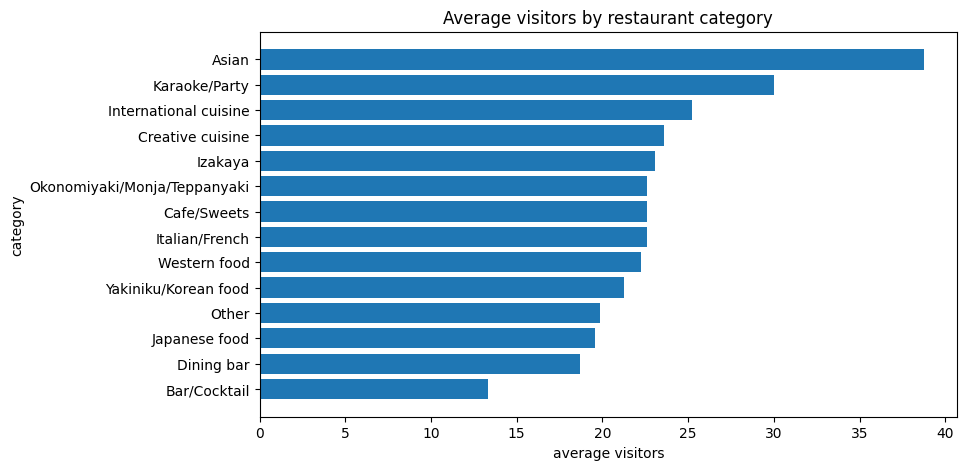

In [29]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_df = category_summary.sort_values('avg_visitors', ascending=True)
ax.barh(plot_df.index, plot_df['avg_visitors'])
ax.set_title('Average visitors by restaurant category')
ax.set_xlabel('average visitors')
ax.set_ylabel('category')
plt.show()

### 8-2. 카테고리 그래프 해석

카테고리별 평균 방문자 수 차이가 나타납니다. 이는 식당 유형에 따라 기본 수요 규모와 방문 패턴이 다를 수 있음을 의미합니다.

| 발견 | 인사이트 | 모델링 반영 |
|---|---|---|
| 카테고리별 평균 방문자 수 차이 | 식당 유형별 수요 패턴이 다를 가능성 | `air_category_name` 피처 유지 |
| 일부 카테고리는 표본 수가 적음 | 평균값이 불안정할 수 있음 | 식당별 평균과 함께 사용 |
| 같은 카테고리 안에서도 식당별 차이 존재 가능 | 카테고리만으로 개별 식당을 설명하기 어려움 | `store_prior_mean`과 함께 사용 |

카테고리 평균은 식당 유형의 큰 방향성을 보여주지만, 개별 식당의 규모를 대체하지는 못합니다.  
따라서 모델링에서는 카테고리 피처와 식당별 과거 방문 피처를 함께 사용하는 것이 적절합니다.

In [30]:
area_summary = (
    train_master.groupby('area_level_1')
    .agg(
        stores=('air_store_id', 'nunique'),
        rows=('visitors', 'size'),
        avg_visitors=('visitors', 'mean'),
        median_visitors=('visitors', 'median')
    )
    .round(2)
    .sort_values('rows', ascending=False)
    .head(12)
)
area_summary

,stores,rows,avg_visitors,median_visitors
area_level_1,,,,
Tōkyō-to,444,133063,20.48,17.0
Fukuoka-ken,127,39645,20.43,16.0
Ōsaka-fu,74,22821,21.34,17.0
Hyōgo-ken,57,17846,23.28,20.0
Hokkaidō,46,13055,21.11,16.0
Hiroshima-ken,32,9858,21.82,18.0
Miyagi-ken,17,5959,20.46,17.0
Shizuoka-ken,18,5798,25.45,20.0
Niigata-ken,14,4063,21.89,19.0


### 8-3. 지역별 방문 패턴 해석

지역은 상권 특성을 간접적으로 반영합니다.  
예를 들어 도심·상업지·주거지·관광지에 따라 평일/주말 수요가 다를 수 있습니다.

| 확인 포인트 | 해석 | 다음 반영 |
|---|---|---|
| 지역별 식당 수 | 일부 지역에 데이터가 집중되어 있을 수 있습니다. | 지역 평균 해석 시 표본 수를 함께 봅니다. |
| 지역별 평균 방문자 수 | 상권별 수요 규모 차이를 보여줍니다. | `area_level_1`, `air_area_name`을 피처 후보로 유지합니다. |
| 지역 세분화 수준 | 너무 세분화하면 카테고리가 많아질 수 있습니다. | Ridge에서는 인코딩 부담이 있고, LightGBM에서는 범주형 처리 전략이 필요합니다. |

---
# 9. 예약 데이터와 실제 방문자 수 관계

예약 데이터가 실제 방문자 수와 얼마나 관련 있는지 확인합니다.  
여기서는 예약 유무, 예약 인원, 예약 리드타임을 나누어 살펴봅니다.

In [31]:
reserve_exist_summary = (
    train_master.groupby('total_reserve_exists')['visitors']
    .agg(['count', 'mean', 'median'])
    .round(2)
    .reset_index()
)
reserve_exist_summary['reserve_status'] = reserve_exist_summary['total_reserve_exists'].map({0: 'No reservation', 1: 'Has reservation'})
reserve_exist_summary[['reserve_status', 'count', 'mean', 'median']]

,reserve_status,count,mean,median
0,No reservation,216410,20.00,16.0
1,Has reservation,35698,26.85,23.0


### 9-1. 예약 유무별 방문자 수 해석

| 관찰 | 해석 | 다음 반영 |
|---|---|---|
| 예약이 없는 날 평균 | 약 20.0명 | 예약 없이도 방문이 발생하는 워크인 수요가 존재합니다. |
| 예약이 있는 날 평균 | 약 26.8명 | 예약이 있는 날은 평균 방문자 수가 더 높은 경향이 있습니다. |
| 평균 차이 | 예약 있는 날이 약 1.3배 높습니다. | 예약 피처는 방문자 수 예측의 중요한 선행 신호 후보입니다. |

단, 예약이 많아서 방문자가 늘어난 것인지, 원래 수요가 높은 날에 예약도 함께 늘어난 것인지는 구분해야 합니다. 따라서 예약 피처는 **인과 원인**이 아니라 **예측 신호**로 해석합니다.

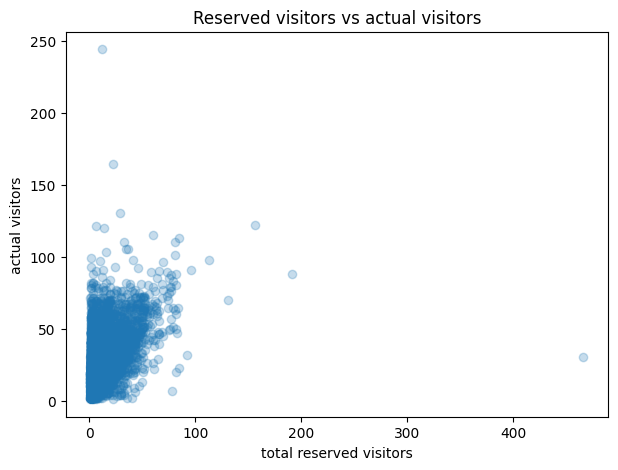

예약 인원 합계와 실제 방문자 수의 상관계수: 0.416


In [32]:
# 예약 인원이 있는 행만 대상으로 실제 방문자 수와의 관계를 확인합니다.
reserved_rows = train_master[train_master['total_reserve_visitors_sum'] > 0].copy()
plot_sample = reserved_rows.sample(min(5000, len(reserved_rows)), random_state=42)
fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(plot_sample['total_reserve_visitors_sum'], plot_sample['visitors'], alpha=0.25)
ax.set_title('Reserved visitors vs actual visitors')
ax.set_xlabel('total reserved visitors')
ax.set_ylabel('actual visitors')
plt.show()
reserve_corr = reserved_rows[['total_reserve_visitors_sum','visitors']].corr().iloc[0,1]
print(f'예약 인원 합계와 실제 방문자 수의 상관계수: {reserve_corr:.3f}')

### 9-2. 예약 인원과 실제 방문자 수 산점도 해석

| 관찰 | 해석 | 다음 반영 |
|---|---|---|
| 상관계수는 약 0.416 | 예약 인원과 실제 방문자 수 사이에 중간 정도의 양의 관계가 있습니다. | `total_reserve_visitors_sum`은 모델 피처로 유지합니다. |
| 산점도가 완전한 직선은 아님 | 예약 인원만으로 실제 방문자 수를 모두 설명할 수 없습니다. | 요일, 카테고리, 식당별 평균, 최근 이동평균과 함께 사용합니다. |
| 실제 방문자가 예약 인원보다 큰 경우가 많음 | 워크인 고객 또는 추가 방문 수요가 존재할 수 있습니다. | 예약 데이터는 전체 수요가 아니라 조기 신호로 해석합니다. |


In [33]:
lead_time_cols = [
    'air_lead_time_mean', 'air_lead_time_median', 'air_lead_time_max',
    'hpg_lead_time_mean', 'hpg_lead_time_median', 'hpg_lead_time_max'
]
lead_time_summary = (
    train_master.loc[train_master['total_reserve_count'] > 0, lead_time_cols]
    .replace(0, np.nan)
    .describe(percentiles=[0.25, 0.5, 0.75, 0.9])
    .round(2)
)
lead_time_summary

,air_lead_time_mean,air_lead_time_median,air_lead_time_max,hpg_lead_time_mean,hpg_lead_time_median,hpg_lead_time_max
count,27125.00,26832.00,27125.00,13510.00,13510.00,13510.00
mean,145.10,128.26,254.58,155.77,150.99,196.09
std,208.72,207.63,332.69,175.75,175.81,227.42
min,0.11,0.50,1.00,0.50,0.50,1.00
25%,27.50,22.00,46.00,42.00,37.00,45.00
50%,86.75,65.00,149.00,98.00,93.00,118.00
75%,185.00,160.00,358.00,212.00,199.00,265.75
90%,338.20,319.00,626.00,364.00,361.00,481.00
max,8429.28,8390.50,9435.00,2169.00,2169.00,2398.00


### 9-3. 예약 리드타임 해석

| 확인 포인트 | 해석 | 다음 반영 |
|---|---|---|
| AIR 예약 리드타임 중앙값 | 방문일 기준 예약 리드타임 중앙값은 약 65시간 수준입니다. | 약 2~3일 전 수요 감지 가능성을 검토할 수 있습니다. |
| HPG 예약 리드타임 중앙값 | 매핑 가능한 HPG 예약의 중앙값은 약 93시간 수준입니다. | 일부 식당에서는 더 이른 시점의 예약 신호가 존재할 수 있습니다. |
| 비즈니스 의미 | 리드타임은 “언제 알 수 있는가”에 대한 답입니다. | D-1/D-3/D-7 예약 피처를 만들어 사전 대응 가능성을 비교합니다. |

리드타임 피처는 단순 예측 정확도뿐 아니라, 점주가 근무표·발주·프로모션을 며칠 전에 조정할 수 있는지를 설명하는 데 사용됩니다.


---
# 10. 피크 수요 후보일·저수요 후보일 정의

점주 관점에서는 평균 오차뿐 아니라, “많이 올 날을 놓치는가”와 “적게 올 날을 과대 준비하는가”가 중요합니다.  
따라서 식당×요일 평균 대비 실제 방문자 수가 높은 날/낮은 날을 후보로 정의합니다.


In [34]:
# 식당×요일 평균 대비 실제 방문자 수 비율을 계산합니다.
# 절대 방문자 수가 아니라 '해당 식당의 평소 요일 기준' 대비 얼마나 높고 낮은지를 봅니다.
train_master['visitor_ratio_vs_store_dow'] = (
    train_master['visitors'] / train_master['store_dow_mean_for_eda'].replace(0, np.nan)
)

# 기준은 분석용 가설입니다. 모델 타깃으로 쓰기보다는 운영 KPI 분석에 활용합니다.
train_master['peak_candidate_flg'] = (train_master['visitor_ratio_vs_store_dow'] >= 1.2).astype(int)
train_master['low_demand_candidate_flg'] = (train_master['visitor_ratio_vs_store_dow'] <= 0.8).astype(int)

peak_low_summary = pd.DataFrame({
    'label': ['Peak candidate', 'Low-demand candidate'],
    'definition': ['actual visitors ≥ store×weekday average × 1.2', 'actual visitors ≤ store×weekday average × 0.8'],
    'row_count': [train_master['peak_candidate_flg'].sum(), train_master['low_demand_candidate_flg'].sum()],
    'share_%': [train_master['peak_candidate_flg'].mean()*100, train_master['low_demand_candidate_flg'].mean()*100]
}).round(2)
peak_low_summary

,label,definition,row_count,share_%
0,Peak candidate,actual visitors ≥ store×weekday average × 1.2,70329,27.90
1,Low-demand candidate,actual visitors ≤ store×weekday average × 0.8,92069,36.52


### 10-1. 피크/저수요 후보 해석

피크 수요 후보일과 저수요 후보일은 `식당×요일 평균`을 기준으로 정의했습니다.

| 구분 | 기준 | 점주 관점 의미 |
|---|---|---|
| 피크 수요 후보일 | 식당×요일 평균 대비 20% 이상 높음 | 인력·재고 추가 준비 후보 |
| 저수요 후보일 | 식당×요일 평균 대비 20% 이상 낮음 | 프로모션·발주 축소·근무 조정 후보 |

이 플래그는 모델의 직접 타깃이라기보다, 모델 성능을 비즈니스적으로 해석하는 기준으로 활용할 수 있습니다. 예를 들어 전체 MAE가 낮아졌는지만 보는 것이 아니라, **피크 후보일에서 과소예측이 줄었는지**, **저수요 후보일에서 과대예측이 줄었는지**를 확인하면 점주 액션과 더 잘 연결됩니다.

| 후보 | 비중 | 해석 | 다음 반영 |
|---|---:|---|---|
| 피크 수요 후보일 | 약 27.9% | 평소 요일 평균보다 20% 이상 방문자가 많은 날입니다. | 과소예측 감소와 피크 탐지율을 운영 KPI로 볼 수 있습니다. |
| 저수요 후보일 | 약 36.5% | 평소 요일 평균보다 20% 이상 방문자가 적은 날입니다. | 과대예측 감소와 저수요 탐지율을 운영 KPI로 볼 수 있습니다. |

이 기준은 정답 라벨이라기보다, 식당 점주의 운영 의사결정을 분석하기 위한 **비즈니스 해석용 라벨**입니다. 모델의 최종 타깃은 여전히 `visitors`입니다.


In [35]:
peak_low_by_dow = (
    train_master.groupby('day_of_week')[['peak_candidate_flg', 'low_demand_candidate_flg']]
    .mean()
    .reindex(dow_order)
    .mul(100)
    .round(2)
    .reset_index()
)
peak_low_by_dow

,day_of_week,peak_candidate_flg,low_demand_candidate_flg
0,Monday,28.98,39.62
1,Tuesday,28.77,38.17
2,Wednesday,28.38,36.80
3,Thursday,28.42,38.26
4,Friday,27.06,33.32
5,Saturday,26.43,33.36
6,Sunday,27.49,37.16


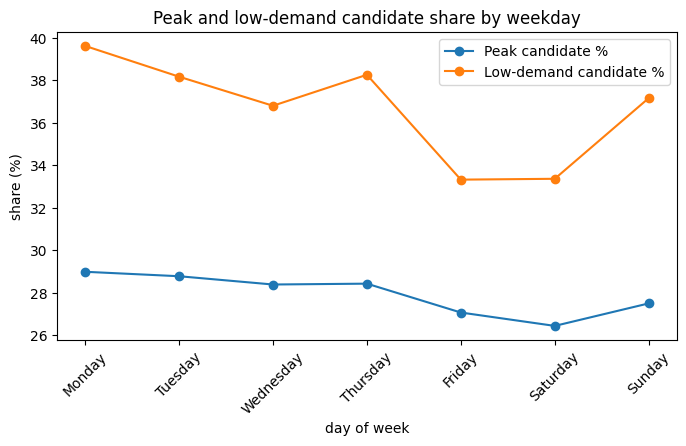

In [36]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(peak_low_by_dow['day_of_week'], peak_low_by_dow['peak_candidate_flg'], marker='o', label='Peak candidate %')
ax.plot(peak_low_by_dow['day_of_week'], peak_low_by_dow['low_demand_candidate_flg'], marker='o', label='Low-demand candidate %')
ax.set_title('Peak and low-demand candidate share by weekday')
ax.set_xlabel('day of week')
ax.set_ylabel('share (%)')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.show()

### 10-2. 요일별 피크/저수요 후보 해석

이 그래프는 특정 요일이 항상 좋거나 나쁘다는 의미가 아닙니다. 각 식당의 요일 평균을 기준으로 “평소보다 더 높았는지/낮았는지”를 본 것입니다.

| 해석 포인트 | 모델링/인사이트 반영 |
|---|---|
| 요일별로 피크 후보일과 저수요 후보일 비중이 다름 | 평균적인 요일 효과만으로는 충분하지 않으며, 식당별 기준선이 필요합니다. |
| 피크와 저수요는 서로 다른 운영 리스크 | 피크 후보일은 과소예측, 저수요 후보일은 과대예측을 별도로 봐야 합니다. |
| 후보 플래그는 평가·해석용 | 모델 학습 타깃이 아니라, 예측 결과를 점주 액션 관점으로 해석하는 기준입니다. |


---
# 11. 결측치 및 품질 점검

전처리 완료 후 최종 master table의 핵심 컬럼의 결측 여부를 확인합니다.  
결측은 무조건 제거하기보다, 그 의미를 구분해 처리해야 합니다.
날짜/식당 정보 결측은 병합 오류일 수 있고, 예약 피처 결측은 앞에서 0으로 처리한 값입니다.

In [37]:
key_cols = [
    'air_store_id', 'visit_date', 'visitors', 'day_of_week', 'holiday_flg',
    'air_category_name', 'area_level_1',
    'total_reserve_count', 'total_reserve_visitors_sum',
    'store_prior_mean', 'store_dow_prior_mean', 'rolling_7_mean', 'rolling_28_mean'
]
missing_summary = (
    train_master[key_cols]
    .isna()
    .sum()
    .to_frame('missing_count')
)
missing_summary['missing_%'] = (missing_summary['missing_count'] / len(train_master) * 100).round(4)
missing_summary

,missing_count,missing_%
air_store_id,0,0.0
visit_date,0,0.0
visitors,0,0.0
day_of_week,0,0.0
holiday_flg,0,0.0
air_category_name,0,0.0
area_level_1,0,0.0
total_reserve_count,0,0.0
total_reserve_visitors_sum,0,0.0
store_prior_mean,0,0.0


### 11-1. 결측치 점검 해석

| 컬럼 그룹 | 해석 | 처리 기준 |
|---|---|---|
| 날짜/식당 기본 정보 | 결측이 있다면 병합 키 또는 날짜 타입 문제일 가능성이 큽니다. | 원인 확인 후 수정합니다. |
| 예약 피처 | 결측은 대부분 예약이 없다는 의미입니다. | 예약 건수/인원은 0으로 처리합니다. |
| 과거 방문 피처 | 첫 관측일에는 과거 데이터가 없을 수 있습니다. | 전체 평균 또는 이전 기준선으로 보완합니다. |
| 타깃 `visitors` | train에는 반드시 존재해야 합니다. | 결측이 있으면 학습 데이터 품질 문제입니다. |

In [38]:
feature_groups = pd.DataFrame({
    'feature_group': ['Key', 'Target', 'Date', 'Store', 'Reservation', 'Historical demand', 'Business flags'],
    'example_columns': [
        'air_store_id, visit_date',
        'visitors, log_visitors',
        'day_of_week, dow_num, holiday_flg, prev_day_holiday, next_day_holiday',
        'air_category_name, air_area_name, area_level_1, latitude, longitude',
        'total_reserve_count, total_reserve_visitors_sum, total_reserve_visitors_d1/d3/d7',
        'store_prior_mean, store_dow_prior_mean, rolling_7_mean, rolling_28_mean',
        'peak_candidate_flg, low_demand_candidate_flg'
    ],
    'use_case': [
        '병합/식별 기준',
        '방문자 수 예측 타깃',
        '요일·휴일 수요 차이 반영',
        '식당 유형·상권 차이 반영',
        '미래 수요 조기 감지 신호',
        'Baseline 및 핵심 예측 피처',
        '운영 KPI와 인사이트 해석용'
    ]
})

print('train_master shape:', train_master.shape)
print('test_master shape :', test_master.shape)
feature_groups


train_master shape: (252108, 72)
test_master shape : (32019, 66)


,feature_group,example_columns,use_case
0,Key,"air_store_id, visit_date",병합/식별 기준
1,Target,"visitors, log_visitors",방문자 수 예측 타깃
2,Date,"day_of_week, dow_num, holiday_flg, prev_day_ho...",요일·휴일 수요 차이 반영
3,Store,"air_category_name, air_area_name, area_level_1...",식당 유형·상권 차이 반영
4,Reservation,"total_reserve_count, total_reserve_visitors_su...",미래 수요 조기 감지 신호
5,Historical demand,"store_prior_mean, store_dow_prior_mean, rollin...",Baseline 및 핵심 예측 피처
6,Business flags,"peak_candidate_flg, low_demand_candidate_flg",운영 KPI와 인사이트 해석용


### 11-2. 최종 피처 그룹과 비즈니스 질문 연결

전처리 결과는 단순히 컬럼 수를 늘린 것이 아니라, 점주의 운영 질문에 맞게 정보를 구조화한 것입니다.

| 점주의 질문 | 연결되는 피처 |
|---|---|
| 사람이 많이 올 날에는 얼마나 준비해야 하지? | 식당별 평균, 식당×요일 평균, 최근 이동평균, 공휴일, 예약 인원 |
| 사람이 적게 올 날에는 어떻게 빈 테이블을 줄이지? | 저수요 후보 플래그, 식당×요일 평균 대비 비율, 최근 수요 하락 신호 |
| 그걸 며칠 전에 알 수 있는 신호는 없을까? | 예약 리드타임, D-1/D-3/D-7 예약량, 예약 존재 여부 |

---
# 12. 모델링 반영 포인트

아래 내용은 전처리·EDA 결과를 모델링에 연결하기 위한 요약입니다.  
모델링 단계에서는 이 표를 기준으로 Baseline, Ridge Regression, LightGBM, SHAP 해석을 구성할 수 있습니다.

In [39]:
modeling_summary = pd.DataFrame([
    ['식당별 평균', 'Baseline', '식당마다 기본 수요 규모가 다름', '식당별 평균 방문자 수로 예측'],
    ['식당×요일 평균', 'Baseline', '요일별 수요 차이가 명확함', '식당별 특정 요일 평균으로 예측'],
    ['최근 이동평균', 'Baseline/ML feature', '최근 수요 흐름을 반영할 수 있음', 'rolling_7/14/28_mean 사용'],
    ['날짜 피처', 'Ridge/LightGBM', '요일·주말·공휴일 효과 반영', 'day_of_week, holiday_flg, prev/next holiday'],
    ['식당 피처', 'Ridge/LightGBM', '카테고리·지역별 기본 수요 차이 반영', 'air_category_name, area_level_1'],
    ['예약 피처', 'Ridge/LightGBM/SHAP', '방문일 이전에 관측 가능한 선행 신호', 'reserve_count, reserve_visitors_sum, lead_time'],
    ['피크/저수요 플래그', 'Evaluation/Insight', '운영 KPI 해석용 라벨', '과소예측/과대예측 및 탐지율 분석'],
], columns=['item', 'recommended_use', 'why_it_matters', 'how_to_use'])
modeling_summary


,item,recommended_use,why_it_matters,how_to_use
0,식당별 평균,Baseline,식당마다 기본 수요 규모가 다름,식당별 평균 방문자 수로 예측
1,식당×요일 평균,Baseline,요일별 수요 차이가 명확함,식당별 특정 요일 평균으로 예측
2,최근 이동평균,Baseline/ML feature,최근 수요 흐름을 반영할 수 있음,rolling_7/14/28_mean 사용
3,날짜 피처,Ridge/LightGBM,요일·주말·공휴일 효과 반영,"day_of_week, holiday_flg, prev/next holiday"
4,식당 피처,Ridge/LightGBM,카테고리·지역별 기본 수요 차이 반영,"air_category_name, area_level_1"
5,예약 피처,Ridge/LightGBM/SHAP,방문일 이전에 관측 가능한 선행 신호,"reserve_count, reserve_visitors_sum, lead_time"
6,피크/저수요 플래그,Evaluation/Insight,운영 KPI 해석용 라벨,과소예측/과대예측 및 탐지율 분석


## Baseline 후보

| Baseline | 의미 | 기대 역할 |
|---|---|---|
| 식당별 평균 | 이 식당은 평소 몇 명 오는가? | 가장 단순한 기준선 |
| 식당×요일별 평균 | 이 식당은 특정 요일에 보통 몇 명 오는가? | 요일 패턴 반영 |
| 최근 이동평균 | 최근 수요 흐름은 어떤가? | 단기 추세 반영 |

## Ridge Regression 후보 피처

| 피처 그룹 | 예시 | 이유 |
|---|---|---|
| 날짜 | 요일, 주말, 공휴일 | 수요의 반복 패턴 반영 |
| 식당 | 카테고리, 지역 | 식당 유형과 상권 차이 반영 |
| 예약 | 예약 건수, 예약 인원, 리드타임 | 조기 수요 신호 반영 |
| 과거 방문 | 식당 평균, 식당×요일 평균, 이동평균 | 기본 수요와 최근 추세 반영 |

## LightGBM + SHAP 해석 방향

| 해석 질문 | 확인할 피처 |
|---|---|
| 피크일을 높게 예측한 이유는 무엇인가? | 요일, 공휴일, 예약 인원, 최근 평균, 식당 카테고리 |
| 저수요 후보일을 낮게 예측한 이유는 무엇인가? | 낮은 예약량, 낮은 rolling 평균, 특정 요일/지역 패턴 |
| 예약 데이터는 실제로 도움이 되었는가? | 예약 피처 포함/제외 모델 성능 비교, SHAP 중요도 |
| 점주는 며칠 전부터 준비할 수 있는가? | 리드타임, D-3/D-7 예약 피처 추가 실험 |

## 비즈니스 KPI 연결

| 모델 결과 | 비즈니스 해석 |
|---|---|
| MAE 감소 | 하루 식당 단위 준비 오차 감소 |
| 피크일 과소예측 감소 | 인력·재고 부족 위험 감소 |
| 저수요 후보일 과대예측 감소 | 과잉 발주·과잉 근무 위험 감소 |
| 예약 피처 추가 후 성능 개선 | 며칠 전 수요 감지 가능성 확인 |

### 12-1. 모델링 연결 해석

전처리·EDA 결과는 모델링에서 다음 흐름으로 연결됩니다.

| 단계 | 역할 |
|---|---|
| Baseline | 식당별 평균, 식당×요일 평균, 최근 이동평균으로 최소 기준선 설정 |
| Ridge Regression | 날짜·식당·예약 피처를 선형적으로 반영했을 때 평균보다 개선되는지 확인 |
| LightGBM | 카테고리×요일, 예약×최근 추세처럼 복잡한 관계 반영 |
| SHAP | 모델이 어떤 신호를 중요하게 사용했는지 해석 |

### 모델 입력 시 제외해야 할 컬럼

아래 컬럼은 EDA·해석·평가에는 유용하지만, 모델의 입력 피처로 그대로 사용하면 데이터 누수 또는 타깃 중복이 발생할 수 있습니다.

| 컬럼 | 제외 이유 |
|---|---|
| `visitors` | 원본 타깃 변수 |
| `log_visitors` | 로그 변환 타깃 변수 |
| `visitor_ratio_vs_store_dow` | 실제 방문자 수를 이용해 만든 EDA용 비율 |
| `peak_candidate_flg` | 실제 방문자 수 기반 비즈니스 해석용 라벨 |
| `low_demand_candidate_flg` | 실제 방문자 수 기반 비즈니스 해석용 라벨 |
| `store_mean_for_eda` | 전체 train 기준 EDA용 평균 |
| `store_dow_mean_for_eda` | 전체 train 기준 EDA용 평균 |
| `category_mean_for_eda` | 전체 train 기준 EDA용 평균 |
| `area_mean_for_eda` | 전체 train 기준 EDA용 평균 |

실제 모델링에서는 `store_prior_mean`, `store_dow_prior_mean`, `rolling_*`처럼 예측 시점 이전 정보를 기준으로 만든 피처를 우선 사용합니다.


In [40]:
target_cols = ['visitors', 'log_visitors']

eda_only_cols = [
    'store_mean_for_eda',
    'store_dow_mean_for_eda',
    'category_mean_for_eda',
    'area_mean_for_eda',
    'visitor_ratio_vs_store_dow',
    'peak_candidate_flg',
    'low_demand_candidate_flg'
]

id_cols = ['air_store_id', 'visit_date', 'dataset', 'id']

model_feature_candidates = [
    c for c in train_master.columns
    if c not in target_cols + eda_only_cols + id_cols
]

model_feature_candidates_df = pd.DataFrame({'feature': model_feature_candidates})

pd.DataFrame({
    'feature_type': ['target', 'eda_only', 'id', 'model_feature_candidates'],
    'columns': [
        ', '.join(target_cols),
        ', '.join(eda_only_cols),
        ', '.join([c for c in id_cols if c in train_master.columns]),
        f'{len(model_feature_candidates)} columns'
    ]
})


,feature_type,columns
0,target,"visitors, log_visitors"
1,eda_only,"store_mean_for_eda, store_dow_mean_for_eda, ca..."
2,id,"air_store_id, visit_date"
3,model_feature_candidates,61 columns


---
# 13. 전처리 산출물 저장

모델링에 사용할 수 있도록 전처리 완료 데이터를 CSV로 저장합니다.

In [43]:
# 최종 산출물은 별도 output 폴더에 저장합니다.
# 기존 파일과 이름이 충돌하면 실행 환경에 따라 PermissionError가 발생할 수 있으므로,
# Notebook을 여러 번 실행해도 안전하도록 저장 폴더와 파일명을 분리합니다.

OUTPUT_DIR = Path('pre_file')
OUTPUT_DIR.mkdir(exist_ok=True)

train_output_path = OUTPUT_DIR / 'recruit_train_master_preprocessed_final.csv'
test_output_path = OUTPUT_DIR / 'recruit_test_master_preprocessed_final.csv'
modeling_summary_path = OUTPUT_DIR / 'recruit_modeling_summary_final.csv'
feature_candidates_path = OUTPUT_DIR / 'recruit_model_feature_candidates_final.csv'

train_master.to_csv(train_output_path, index=False)
test_master.to_csv(test_output_path, index=False)
modeling_summary.to_csv(modeling_summary_path, index=False)
model_feature_candidates_df.to_csv(feature_candidates_path, index=False)

print('저장 완료')
print(f'train master: {train_output_path}')
print(f'test master: {test_output_path}')
print(f'modeling summary: {modeling_summary_path}')
print(f'feature candidates: {feature_candidates_path}')

저장 완료
train master: pre_file/recruit_train_master_preprocessed_final.csv
test master: pre_file/recruit_test_master_preprocessed_final.csv
modeling summary: pre_file/recruit_modeling_summary_final.csv
feature candidates: pre_file/recruit_model_feature_candidates_final.csv


---
# 14. 최종 정리

이번 Notebook에서는 여러 원본 CSV를 `air_store_id × visit_date` 단위로 통합해 방문자 수 예측용 master table을 만들었습니다.  
전처리와 EDA를 통해 방문자 수 예측에 필요한 날짜, 식당, 예약, 과거 방문 패턴 피처를 정리했습니다.

| 핵심 결과 | 의미 | 이후 활용 |
|---|---|---|
| `train_master`, `test_master` 생성 | 학습/예측 데이터의 기준 단위를 통일 | 모델 학습 및 예측 |
| 방문자 수 분포 확인 | low visitor 구간과 일부 피크 수요 존재 | RMSLE/MAE 병행, 피크/저수요 분석 |
| 요일·공휴일 패턴 확인 | 날짜에 따른 반복 수요 존재 | 날짜 피처 및 식당×요일 Baseline |
| 식당별 규모 차이 확인 | 전체 평균 하나로는 예측 어려움 | 식당별 평균, rolling 피처 |
| 카테고리·지역 차이 확인 | 식당 유형과 상권 차이 존재 | 카테고리/지역 피처 |
| 예약 신호 확인 | 예약은 미래 수요를 미리 알려주는 보조 신호 | 예약 인원, 리드타임, D-1/D-3/D-7 피처 |

이후 모델링에서는 평균 Baseline으로 최소 기준선을 세우고, Ridge Regression과 LightGBM을 통해 날짜·식당·예약·과거 방문 패턴을 함께 반영합니다.  
마지막으로 SHAP를 활용하면 모델이 방문자 수를 높게 또는 낮게 예측한 근거를 식당 점주의 운영 액션과 연결할 수 있습니다.